# Vertical interpolation

This small notebook is meant to show vertical interpolation possibilities with AQUA. The method is included in the `Reader` but it is nothing more than a wrapper of the Xarray built-in `interp()` function. 
Let's see a few example!

## EN4

Let's open some 3d data, and ask them to regrid so that we can plot them

In [2]:
from aqua import Reader

reader = Reader(model="EN4", exp="v4.2.2", source="monthly-netcdf", regrid="r100", fix=False)
data = reader.retrieve()
data

/work/bb1153/b382076/mambaforge/envs/aqua-new/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/work/bb1153/b382076/mambaforge/envs/aqua-new/lib/python3.14/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/work/bb1153/b382076/mambaforge/envs/aqua-new/lib/python3.14/site-packages/intake/catalog/utils.py:182: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/work/bb1153/b382076/mambaforge/envs/aqua-new/lib/python3.14/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/work/bb1153/b3820

<xarray.Dataset> Size: 39GB
Dimensions:             (time: 900, bnds: 2, lon: 360, lat: 180, depth: 42)
Coordinates:
  * time                (time) datetime64[us] 7kB 1950-01-16T12:00:00 ... 202...
  * lon                 (lon) float64 3kB 1.0 2.0 3.0 4.0 ... 358.0 359.0 360.0
  * lat                 (lat) float64 1kB -90.0 -89.0 -88.0 ... 87.0 88.0 89.0
  * depth               (depth) float32 168B 5.022 15.08 ... 5.051e+03 5.35e+03
Dimensions without coordinates: bnds
Data variables:
    time_bnds           (time, bnds) datetime64[us] 14kB dask.array<chunksize=(12, 2), meta=np.ndarray>
    lon_bnds            (lon, bnds) float64 6kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    lat_bnds            (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    depth_bnds          (depth, bnds) float32 336B dask.array<chunksize=(42, 2), meta=np.ndarray>
    so                  (time, depth, lat, lon) float32 10GB dask.array<chunksize=(12, 1, 180, 360), meta=np.ndarray>
    so_uncertainty      (time, depth, lat, lon) float32 10GB dask.array<chunksize=(12, 1, 180, 360), meta=np.ndarray>
    thetao              (time, depth, lat, lon) float32 10GB dask.array<chunksize=(12, 1, 180, 360), meta=np.ndarray>
    thetao_uncertainty  (time, depth, lat, lon) float32 10GB dask.array<chunksize=(12, 1, 180, 360), meta=np.ndarray>
Attributes: (12/25)
    CDI:                    Climate Data Interface version 2.5.0 (https://mpi...
    Conventions:            CF-1.0
    institution:            UK Met Office
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    ...                     ...
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...
    history:                Wed Oct 01 16:37:11 2025: cdo -f nc4 -z zip selye...
    NCO:                    netCDF Operators version 4.9.2 (Homepage = http:/...
    CDO:                    Climate Data Operators version 2.5.0 (https://mpi...

We exploit 3D regridding and we create a more practical dataset. Please be aware for oceanic dataset that it is mandatory to interpolate on the horizontal grid before interpolating on the vertical axis, while this should not be necessary for atmospheric datasets. This is because weights for regridding are available on the original vertical levels, and in the ocean this will not work if you move to a different vertical level. On the other hand, for the atmosphere weights are not dependent on the vertical level so the operation can be done in any order 

2026-08-05 14:46:08 | smmregrid.Regrid |  WARNING -> Found scalar coordinates ['time', 'depth']. If have selected a along a masked dimensions,regridding might fail. Please consider subsetting with [] or with slice
Matplotlib is building the font cache; this may take a moment.


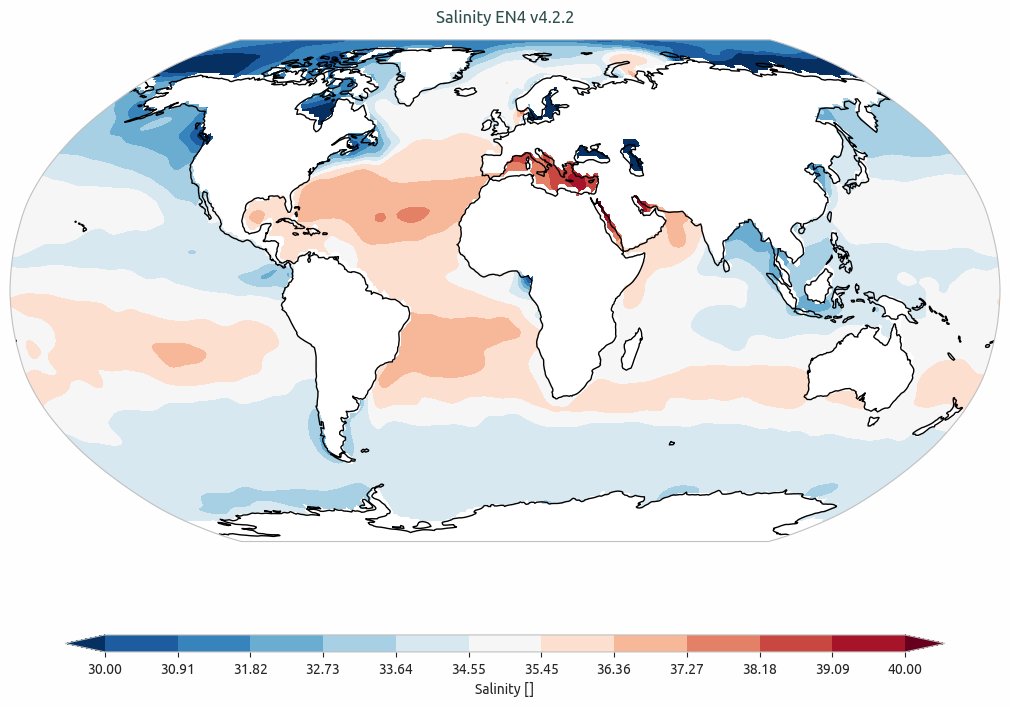

In [4]:
data.so.isel(time=1).isel(depth=1).aqua.regrid().aqua.plot_single_map(vmin=30, vmax=40)

EN4 data has one vertical axe `lev` (unfixed name of axe). We can then simply call the `vertinterp()` method. For convenience we subselect 5 timesteps and then simply plot it.

2026-08-05 14:46:36 :: VertInterpolator :: WARNING  -> Units of level_coord=depth has not defined, reading from the data


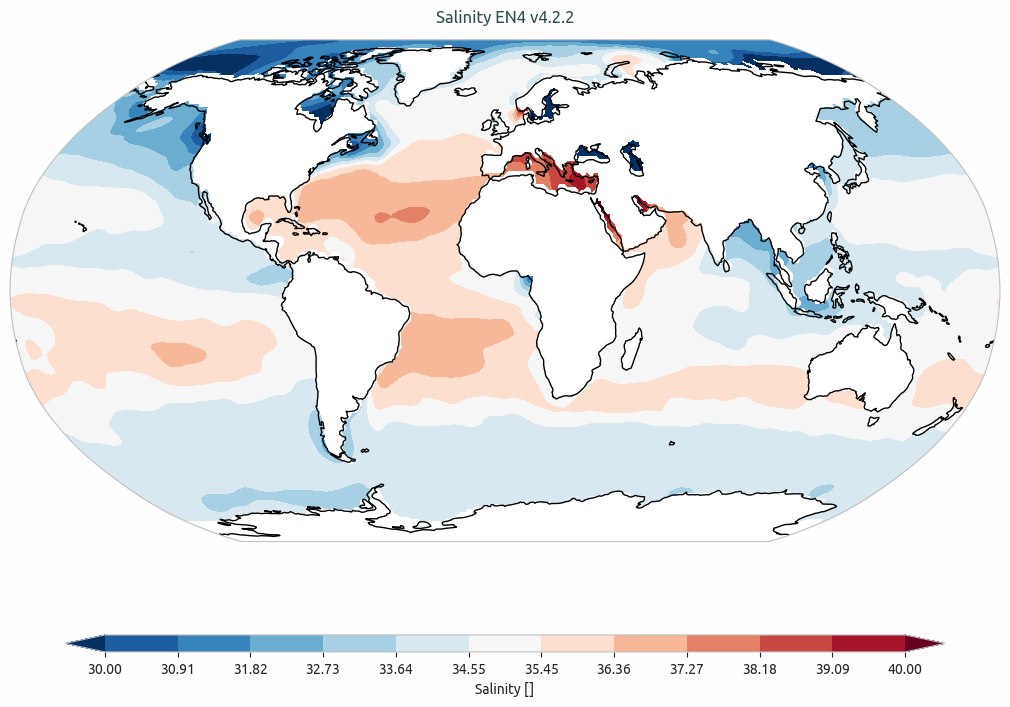

In [5]:
data_interp = data.so.isel(time=slice(0, 5)).aqua.regrid().aqua.vertinterp(levels=[10, 20], level_coord="depth")
data_interp.isel(time=1).isel(depth=1).aqua.plot_single_map(vmin=30, vmax=40)

Please note that this is not identical from the previous plot, i.e. the vertical interpolation works as expected. 

2026-08-05 14:46:50 | smmregrid.Regrid |  WARNING -> Found scalar coordinates ['time', 'depth']. If have selected a along a masked dimensions,regridding might fail. Please consider subsetting with [] or with slice


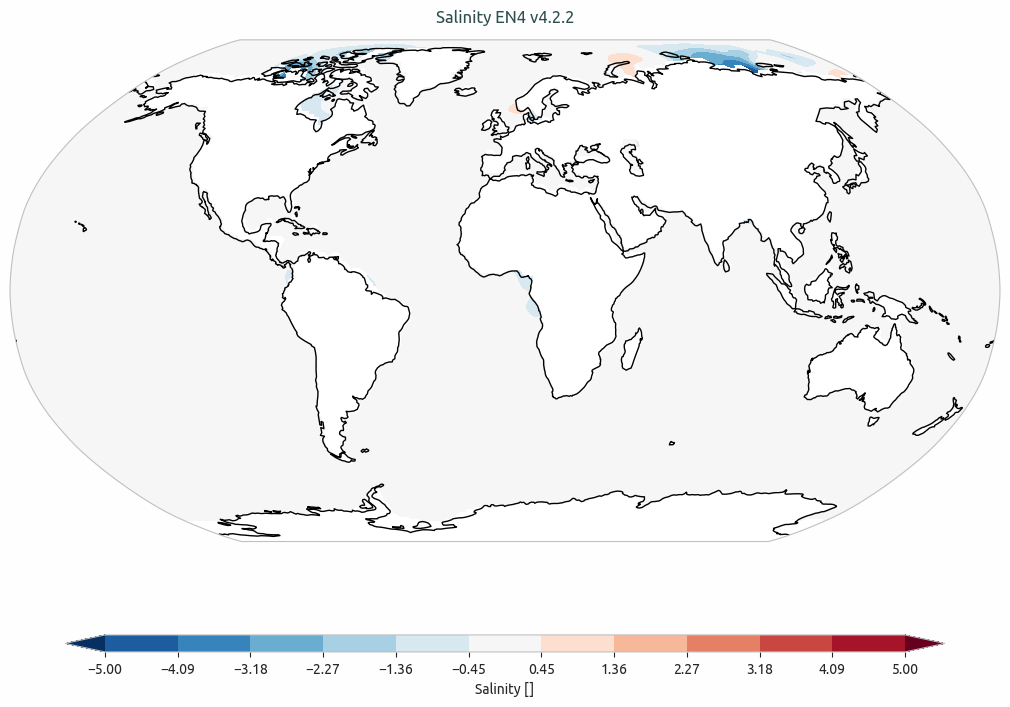

In [6]:
difference = data.so.isel(time=1).isel(depth=0).aqua.regrid() - data_interp.isel(time=1).isel(depth=0)
difference.aqua.plot_single_map(vmin=-5, vmax=5)

## ERA5

Another example of what can be achieved with the vertical interpolation can be shown with ERA5

In [7]:
reader = Reader(model="ERA5", exp="era5", source="monthly", regrid="r100")
data = reader.retrieve()
data

/work/bb1153/b382076/mambaforge/envs/aqua-new/lib/python3.14/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/work/bb1153/b382076/mambaforge/envs/aqua-new/lib/python3.14/site-packages/intake/catalog/utils.py:182: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/work/bb1153/b382076/mambaforge/envs/aqua-new/lib/python3.14/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/work/bb1153/b382076/mambaforge/envs/aqua-new/lib/python3.14/site-packages/intake/catalog/utils.py:182: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")


<xarray.Dataset> Size: 246GB
Dimensions:   (time: 1020, lon: 1440, lat: 721, plev: 8)
Coordinates:
  * time      (time) datetime64[us] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
  * lon       (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * plev      (plev) float64 64B 1e+03 5e+03 1e+04 ... 7e+04 8.5e+04 1e+05
Data variables: (12/30)
    10u       (time, lat, lon) float32 4GB dask.array<chunksize=(12, 721, 1440), meta=np.ndarray>
    10v       (time, lat, lon) float32 4GB dask.array<chunksize=(12, 721, 1440), meta=np.ndarray>
    2t        (time, lat, lon) float32 4GB dask.array<chunksize=(12, 721, 1440), meta=np.ndarray>
    ie        (time, lat, lon) float32 4GB dask.array<chunksize=(12, 721, 1440), meta=np.ndarray>
    hcc       (time, lat, lon) float32 4GB dask.array<chunksize=(12, 721, 1440), meta=np.ndarray>
    lcc       (time, lat, lon) float32 4GB dask.array<chunksize=(12, 721, 1440), meta=np.ndarray>
    ...        ...
    tcc       (time, lat, lon) float32 4GB dask.array<chunksize=(12, 721, 1440), meta=np.ndarray>
    tciw      (time, lat, lon) float32 4GB dask.array<chunksize=(12, 721, 1440), meta=np.ndarray>
    tclw      (time, lat, lon) float32 4GB dask.array<chunksize=(12, 721, 1440), meta=np.ndarray>
    tprate    (time, lat, lon) float32 4GB dask.array<chunksize=(12, 721, 1440), meta=np.ndarray>
    u         (time, plev, lat, lon) float32 34GB dask.array<chunksize=(12, 1, 721, 1440), meta=np.ndarray>
    v         (time, plev, lat, lon) float32 34GB dask.array<chunksize=(12, 1, 721, 1440), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.2.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Oct 08 17:59:06 2025: cdo -O -s -f nc4 -z zip -cat /wor...
    CDO:          Climate Data Operators version 2.2.0 (https://mpimet.mpg.de...

We just select one variable, and then we ask to perform the vertical interpolation. Please note that we will convert the unit asking a specific units for the vertical axis. We ask for a single specific vertical level, and we plot it after regridding. 

2026-08-05 14:47:14 :: VertInterpolator :: WARNING  -> Converting level_coord units to interpolate from Pa to hPa
2026-08-05 14:47:14 | smmregrid.Regrid |  WARNING -> Found scalar coordinates ['plev']. If have selected a along a masked dimensions,regridding might fail. Please consider subsetting with [] or with slice


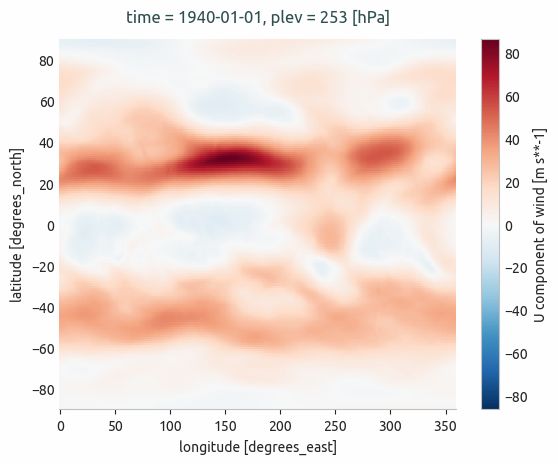

In [8]:
interp = reader.vertinterp(data["u"].isel(time=[0, 1]), levels=253, level_coord="plev", units="hPa")
final = reader.regrid(interp)
final.isel(time=0).plot()